Libraries to import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Import the dataset

In [3]:
file_path = "Network_traffic.csv"

In [7]:
df = pd.read_csv(file_path)

To check and verify the **data**

In [11]:
df.head()

,packet_size,duration,src_bytes,dst_bytes,random_noise,label
0,396.845182,51.859503,1304.806630,589.954220,1.236318,0
1,601.821953,-23.448005,1039.530731,689.063467,1.184756,0
2,591.407849,69.907214,1396.401578,1150.440727,-1.238966,0
3,495.067722,55.036070,894.092684,1288.312194,-1.277913,0
4,677.520742,34.485532,1513.353890,1104.537380,0.535121,0


In [12]:
df.shape

(5150, 6)

In [14]:
y = df['label']
print(y.value_counts())

label
0    5000
1     150
Name: count, dtype: int64


To train SVM model we need to import following sklearn libraries \

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


Train-Test Split- From the dataset we drop label column and add it to X variable and then add the Label column to y variable

In [16]:
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

Feature Scaling

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train SVM Model- We use  SVC(kernel='rbf', gamma='scale')-because anomaly boundaries are usually nonlinear-This configuration is widely used for handling non-linear data by implicitly mapping it into a higher-dimensional space where a linear decision boundary can be found.

In [18]:
svm_model = SVC(kernel='rbf', gamma='scale')
svm_model.fit(X_train, y_train)

SVC()

Prediction

In [19]:
y_pred = svm_model.predict(X_test)

Evaluation

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9922330097087378

Confusion Matrix:
 [[1503    0]
 [  12   30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1503
           1       1.00      0.71      0.83        42

    accuracy                           0.99      1545
   macro avg       1.00      0.86      0.91      1545
weighted avg       0.99      0.99      0.99      1545



The model correctly classified 99.22% of all samples, with 1503 normal traffic instances correctly identified and zero false alarms, while 30 anomalies were correctly detected and 12 anomalies were missed; it achieves 99% precision and 100% recall for normal traffic, meaning it almost never misclassifies normal data, and for anomaly detection it has 100% precision (no false positives) but 71% recall, meaning it detects most but not all attacks, resulting in an F1-score of 0.83 for anomalies; the macro average (treating
both classes equally) shows overall balanced performance of 0.91 F1, while the weighted average remains very high (0.99) due to the large number of normal samples dominating the dataset.

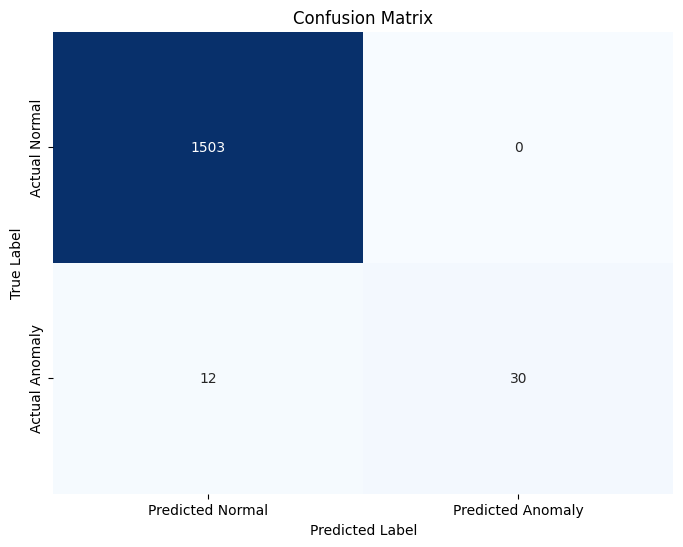

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

1503 → Normal traffic correctly predicted as normal (True Negatives).

0 → Normal traffic wrongly predicted as anomaly (False Positives).

12 → Anomalies wrongly predicted as normal (False Negatives).

30 → Anomalies correctly predicted as anomaly (True Positives).

Actual 0 - Means the actual Data is 0 but the prediction is 1503 times 0 and 0 times wrong prediction or false 0 or false positionve

Actual 1- Means actual data is 1 but it showed 12 times 1 and 30 zeor- It means that 12 times it showed false nagetive and 30 it showed true positive

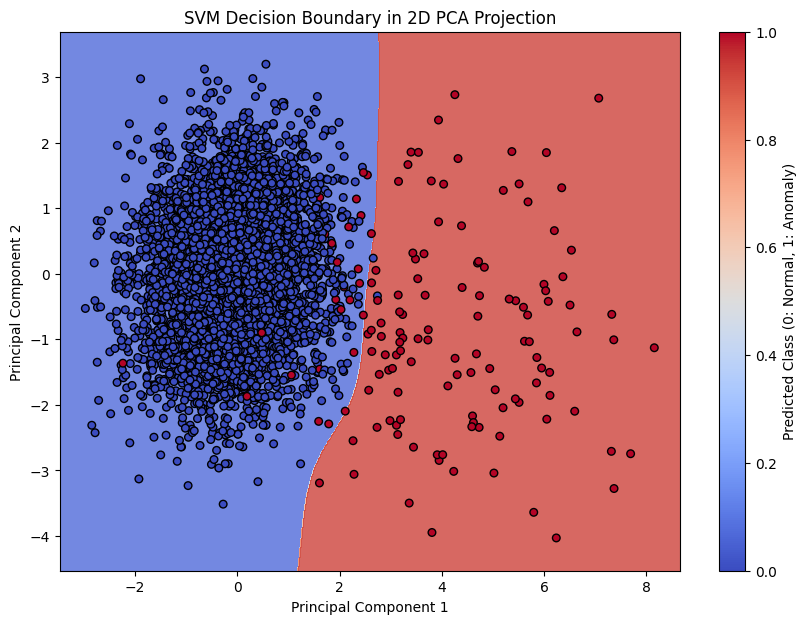

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Combine the scaled training and test data for a comprehensive PCA fit
X_combined_scaled = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))

# Apply PCA for dimensionality reduction to 2 components for visualization
pca_visualizer = PCA(n_components=2)
X_pca_visual = pca_visualizer.fit_transform(X_combined_scaled)

# Train a new SVM model specifically for visualization on the 2D PCA-transformed data
# This model's decision boundary will be plotted.
# We use the same kernel and gamma as the original SVM for consistency in type of separation.
svm_visual_model = SVC(kernel='rbf', gamma='scale')
svm_visual_model.fit(X_pca_visual, y_combined)

# Create a meshgrid to plot the decision boundary
# Determine the range for the plot based on the PCA-transformed data
x_min, x_max = X_pca_visual[:, 0].min() - 0.5, X_pca_visual[:, 0].max() + 0.5
y_min, y_max = X_pca_visual[:, 1].min() - 0.5, X_pca_visual[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict the class for each point in the meshgrid
Z = svm_visual_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the actual data points
# Use the labels to color the points for better visualization
plt.scatter(X_pca_visual[:, 0], X_pca_visual[:, 1], c=y_combined, cmap=plt.cm.coolwarm, s=30, edgecolors='k')

# Add labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM Decision Boundary in 2D PCA Projection')
plt.colorbar(label='Predicted Class (0: Normal, 1: Anomaly)')
plt.show()